In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
import sunpy.visualization.colormaps as sunpycm
from sunpy.visualization.colormaps import color_tables
import torch
from omegaconf import OmegaConf
from loguru import logger as lgr_logger

from sdofmv2.core import MAE, MAE_v1, SDOMLDataModule, inverse_log_norm
from sdofmv2.utils import ALL_WAVELENGTHS, ALL_COMPONENTS

/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cfg = OmegaConf.load(
    "../../../configs/pretrain/pretrain_mae_ALL.yaml"
    )

cfg_old = OmegaConf.load(
    "../../../configs/pretrain/pretrain_mae_AIA_old.yaml"
)

In [3]:
def get_file_name(file_path: str):
    file = Path(file_path)
    return file.name

In [4]:
cache_dir = "../../../assets/cache/ALL/"
train_index = get_file_name(cfg.data.train_index)
val_index = get_file_name(cfg.data.val_index)
test_index = get_file_name(cfg.data.test_index)

data_module = SDOMLDataModule(
    hmi_path=os.path.join(
        cfg.data.sdoml.base_directory, 
        cfg.data.sdoml.sub_directory.hmi
    ) if cfg.data.sdoml.sub_directory.hmi else None,
    aia_path=os.path.join(
        cfg.data.sdoml.base_directory,
        cfg.data.sdoml.sub_directory.aia,
    ) if cfg.data.sdoml.sub_directory.aia else None,
    eve_path=None,
    components=cfg.data.sdoml.components,
    wavelengths=cfg.data.sdoml.wavelengths,
    ions=cfg.data.sdoml.ions,
    batch_size=cfg.model.misc.batch_size,
    num_workers=cfg.data.num_workers,
    train_index=cache_dir + train_index,
    val_index=cache_dir + val_index,
    test_index=cache_dir + test_index,
    num_frames=cfg.model.mae.num_frames,
    drop_frame_dim=cfg.data.drop_frame_dim,
    apply_mask=cfg.data.sdoml.apply_mask,
    precision=cfg.experiment.precision,
    normalization=cfg.data.sdoml.normalization,
    normalization_stat_path=cache_dir,
)
data_module.setup()

data_module_for_old = SDOMLDataModule(
    hmi_path=os.path.join(
        cfg_old.data.sdoml.base_directory, 
        cfg_old.data.sdoml.sub_directory.hmi
    ) if cfg_old.data.sdoml.sub_directory.hmi else None,
    aia_path=os.path.join(
        cfg_old.data.sdoml.base_directory,
        cfg_old.data.sdoml.sub_directory.aia,
    ) if cfg_old.data.sdoml.sub_directory.aia else None,
    eve_path=None,
    components=cfg_old.data.sdoml.components,
    wavelengths=cfg_old.data.sdoml.wavelengths,
    ions=cfg_old.data.sdoml.ions,
    batch_size=cfg_old.model.misc.batch_size,
    num_workers=cfg_old.data.num_workers,
    train_index=cache_dir + train_index,
    val_index=cache_dir + val_index,
    test_index=cache_dir + test_index,
    num_frames=cfg_old.model.mae.num_frames,
    drop_frame_dim=cfg_old.data.drop_frame_dim,
    apply_mask=cfg_old.data.sdoml.apply_mask,
    precision=cfg_old.experiment.precision,
    normalization=cfg_old.data.sdoml.normalization,
    normalization_stat_path="../../../assets/cache/AIA/",
    hmi_mask_path="../../../assets/cache/hmi_mask_512x512.npy"
)
data_module_for_old.setup()

2026-06-26 01:16:07.898 | INFO     | sdofmv2.core.datamodule:setup:637 - Train dataloader is ready!
2026-06-26 01:16:07.900 | INFO     | sdofmv2.core.datamodule:setup:638 - Dataset size: 223044
2026-06-26 01:16:08.020 | INFO     | sdofmv2.core.datamodule:setup:656 - Validation dataloader is ready!
2026-06-26 01:16:08.028 | INFO     | sdofmv2.core.datamodule:setup:657 - Dataset size: 23123
2026-06-26 01:16:09.531 | INFO     | sdofmv2.core.datamodule:setup:675 - test dataloader is ready!
2026-06-26 01:16:09.532 | INFO     | sdofmv2.core.datamodule:setup:676 - Dataset size: 270785
2026-06-26 01:16:10.694 | INFO     | sdofmv2.core.datamodule:setup:637 - Train dataloader is ready!
2026-06-26 01:16:10.696 | INFO     | sdofmv2.core.datamodule:setup:638 - Dataset size: 223044
2026-06-26 01:16:10.806 | INFO     | sdofmv2.core.datamodule:setup:656 - Validation dataloader is ready!
2026-06-26 01:16:10.808 | INFO     | sdofmv2.core.datamodule:setup:657 - Dataset size: 23123
2026-06-26 01:16:12.059

In [5]:
aia_list = (
    ALL_WAVELENGTHS
    if cfg.data.sdoml.sub_directory.aia and cfg.data.sdoml.wavelengths is None
    else cfg.data.sdoml.wavelengths or []
)

hmi_list = (
    ALL_COMPONENTS
    if cfg.data.sdoml.sub_directory.hmi and cfg.data.sdoml.components is None
    else cfg.data.sdoml.components or []
)

aia_list.sort()
hmi_list.sort()
chan_types = aia_list + hmi_list

cms = [
    sunpycm.cmlist.get("sdoaia131"),
    sunpycm.cmlist.get("sdoaia1600"),
    sunpycm.cmlist.get("sdoaia1700"),
    sunpycm.cmlist.get("sdoaia171"),
    sunpycm.cmlist.get("sdoaia193"),
    sunpycm.cmlist.get("sdoaia211"),
    sunpycm.cmlist.get("sdoaia304"),
    sunpycm.cmlist.get("sdoaia335"),
    sunpycm.cmlist.get("sdoaia94"),
    color_tables.hmi_mag_color_table(),
    color_tables.hmi_mag_color_table(),
    color_tables.hmi_mag_color_table(),
]

In [8]:
ckpt_dir = "../../../assets/checkpoints/backbone/"
model = MAE.load_from_checkpoint(
    checkpoint_path=ckpt_dir+"ALL/id_tnzqmrb2_mae_all_base_epoch=4-step=3600-val_loss=0.06.ckpt", 
    map_location="cpu",
    weights_only=False)
lgr_logger.info(f"masking ratio of sdofmv2: {model.masking_ratio}")

model_old = MAE_v1.load_from_checkpoint(
    checkpoint_path=ckpt_dir + "pretrained_mae_e128.ckpt", 
    map_location="cpu",
    weights_only=False,
    optimizer_dict=None,
    scheduler_dict=None
)
lgr_logger.info(f"masking ratio of sdofmv1: {model_old.masking_ratio}")

2026-06-26 01:21:45.165 | INFO     | __main__:<module>:6 - masking ratio of sdofmv2: 0.2
2026-06-26 01:21:52.529 | INFO     | __main__:<module>:15 - masking ratio of sdofmv1: 0.5


In [9]:
timestamps = [
    "2011-12-25 00:12:00",
    "2012-12-25 00:12:00",
    "2013-12-25 00:12:00",
    ]

img_indices = [
    data_module.test_ds.aligndata.index.get_loc(
        pd.to_datetime(i_time)
    ) for i_time in timestamps
]
x_set = torch.cat([data_module.test_ds[i][0].unsqueeze(0) for i in img_indices], dim=0)
ts = [pd.to_datetime(data_module.test_ds[i][1]) for i in img_indices]

x_set_old = torch.cat([data_module_for_old.test_ds[i][0].unsqueeze(0) for i in img_indices], dim=0)
ts_old = [pd.to_datetime(data_module_for_old.test_ds[i][1]) for i in img_indices]

In [10]:
model.eval()

with torch.no_grad():
    output = model(x_set)
    output_old = model_old(x_set_old)

In [11]:
# inverse transformation of hmi
for i_img in range(x_set.shape[0]):
    for ch_id, ch in enumerate(chan_types[-3:]):

        x_set[i_img, ch_id+9, 0, :, :] = inverse_log_norm(
            x_set[i_img, ch_id+9, 0, :, :],
            data_module.normalization_stat,
            ch,
            cfg.data.sdoml.normalization.scaler_factor,
        )

        output[0][i_img, ch_id+9, 0, :, :] = inverse_log_norm(
            output[0][i_img, ch_id+9, 0, :, :],
            data_module.normalization_stat,
            ch,
            cfg.data.sdoml.normalization.scaler_factor,
        )

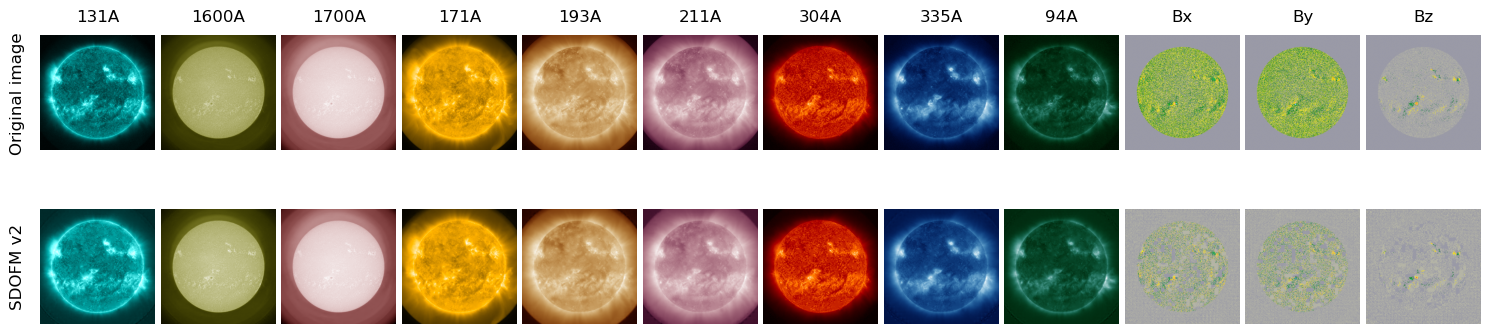

In [12]:
fig, axes = plt.subplots(nrows=2, ncols=12, figsize=(16, 4))
norm = TwoSlopeNorm(vmin=-4000, vcenter=0, vmax=4000)
for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

for i, col in enumerate(chan_types):
    
    axes[0][i].set_title(f"{col}", fontsize=12, pad=10)
    axes[0][i].imshow(x_set[0, i, 0, :, :], cmap=cms[i], norm=norm if i>=9 else None)
    axes[1][i].imshow(output[0][0, i, 0, :, :], cmap=cms[i], norm=norm if i>=9 else None)

row_info = ["Original image", "SDOFM v2"]

for row_idx in range(2):
    axes[row_idx][0].text(
        -0.2, 0.5,              # Negative x moves it to the left
        f"{row_info[row_idx]}", 
        ha='center', 
        va='center', 
        fontsize=12, 
        rotation=90,
        transform=axes[row_idx][0].transAxes # Ensures coordinates are relative to the subplot
    )

plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.05, right=0.95, top=0.9, bottom=0.05)

plt.savefig(f"SDOFMv2_results_per_wavelengh.pdf", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_666940/135498086.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  lim_aia_v1 = np.quantile(np.abs(err_mask_v1), 0.99999)
/tmp/ipykernel_666940/135498086.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  lim_aia_v2 = np.quantile(np.abs(err_mask_v2), 0.99999)


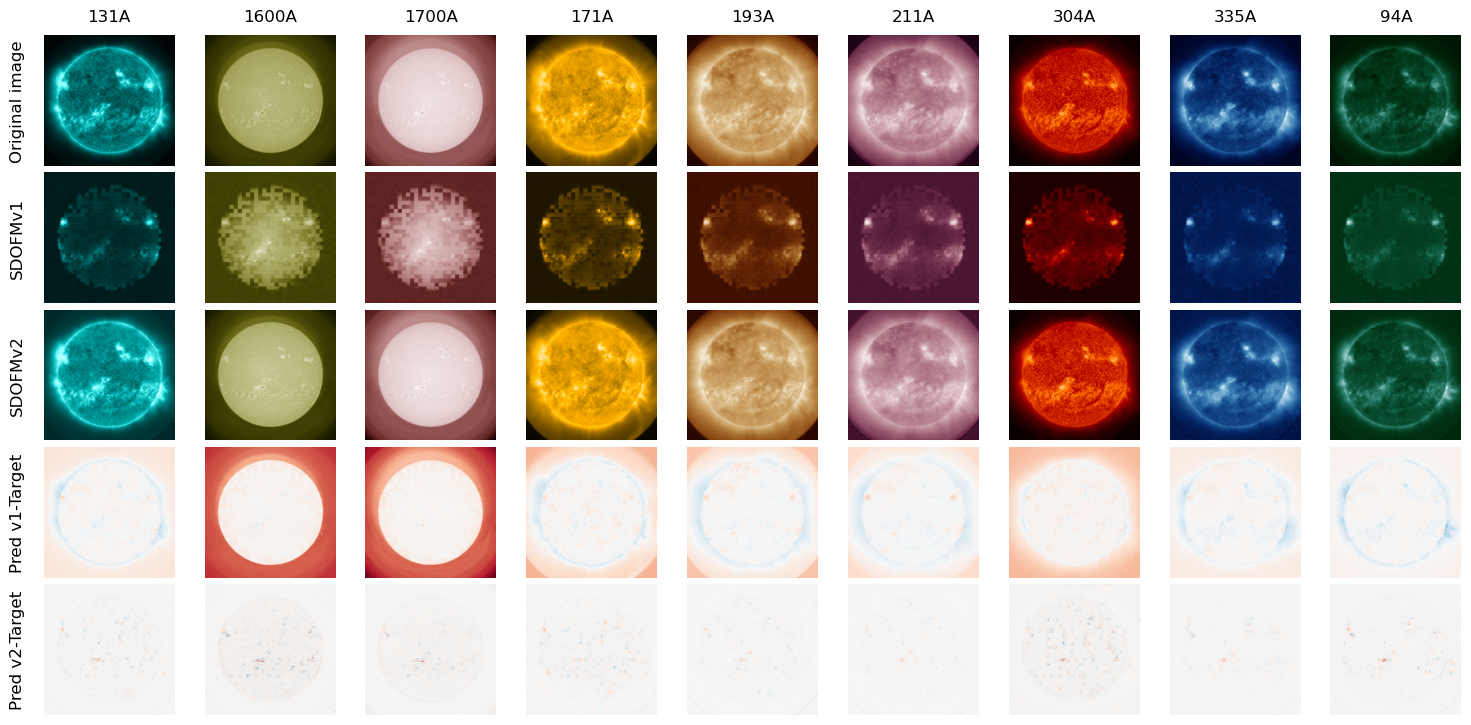

In [13]:
# error norm for AIA
err_mask_v2 = output[0][0, :9, 0, :, :] - x_set[0, :9, 0, :, :]
err_mask_v1 = output_old[1][0, :, 0, :, :] - x_set[0, :9, 0, :, :]
lim_aia_v1 = np.quantile(np.abs(err_mask_v1), 0.99999)
lim_aia_v2 = np.quantile(np.abs(err_mask_v2), 0.99999)
norm_aia_v1 = TwoSlopeNorm(vmin=-lim_aia_v1, vcenter=0, vmax=lim_aia_v1)
norm_aia_v2 = TwoSlopeNorm(vmin=-lim_aia_v2, vcenter=0, vmax=lim_aia_v2)


fig, axes = plt.subplots(nrows=5, ncols=9, figsize=(16, 8))

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

for i, col in enumerate(chan_types[:9]):
    
    axes[0][i].set_title(f"{col}", fontsize=12, pad=10)
    axes[0][i].imshow(x_set[0, i, 0, :, :], cmap=cms[i])
    axes[1][i].imshow(output_old[1][0, i, 0, :, :], cmap=cms[i])
    axes[2][i].imshow(output[0][0, i, 0, :, :], cmap=cms[i])

    # error
    axes[3][i].imshow(output_old[1][0, i, 0, :, :] - x_set[0, i, 0, :, :], cmap='RdBu_r', norm=norm_aia_v1)
    axes[4][i].imshow(output[0][0, i, 0, :, :] - x_set[0, i, 0, :, :], cmap='RdBu_r', norm=norm_aia_v2)
    

    

row_info = ["Original image", "SDOFMv1", "SDOFMv2", "Pred v1-Target", "Pred v2-Target"]

for row_idx in range(5):
    axes[row_idx][0].text(
        -0.2, 0.5,              # Negative x moves it to the left
        f"{row_info[row_idx]}", 
        ha='center', 
        va='center', 
        fontsize=12, 
        rotation=90,
        transform=axes[row_idx][0].transAxes # Ensures coordinates are relative to the subplot
    )

plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.05, right=0.95, top=0.9, bottom=0.05)

plt.savefig(f"SDOFMv2_results_AIA_per_wavelengh.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# error norm for AIA
err_mask_v2 = output[0][0, :9, 0, :, :] - x_set[0, :9, 0, :, :]
err_mask_v1 = output_old[1][0, :, 0, :, :] - x_set[0, :9, 0, :, :]
lim_aia_v1 = np.quantile(np.abs(err_mask_v1), 0.99999)
lim_aia_v2 = np.quantile(np.abs(err_mask_v2), 0.99999)
norm_aia_v1 = TwoSlopeNorm(vmin=-lim_aia_v1, vcenter=0, vmax=lim_aia_v1)
norm_aia_v2 = TwoSlopeNorm(vmin=-lim_aia_v2, vcenter=0, vmax=lim_aia_v2)


fig, axes = plt.subplots(nrows=5, ncols=9, figsize=(16, 8))

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

for i, col in enumerate(chan_types[:9]):
    
    axes[0][i].set_title(f"{col}", fontsize=12, pad=10)
    axes[0][i].imshow(x_set[0, i, 0, :, :], cmap=cms[i])
    axes[1][i].imshow(output_old[1][0, i, 0, :, :], cmap=cms[i])
    axes[2][i].imshow(output[0][0, i, 0, :, :], cmap=cms[i])

    # error
    axes[3][i].imshow(output_old[1][0, i, 0, :, :] - x_set[0, i, 0, :, :], cmap='RdBu_r', norm=norm_aia_v1)
    axes[4][i].imshow(output[0][0, i, 0, :, :] - x_set[0, i, 0, :, :], cmap='RdBu_r', norm=norm_aia_v2)
    

    

row_info = ["Original image", "SDOFMv1", "SDOFMv2", "Pred v1-Target", "Pred v2-Target"]

for row_idx in range(5):
    axes[row_idx][0].text(
        -0.2, 0.5,              # Negative x moves it to the left
        f"{row_info[row_idx]}", 
        ha='center', 
        va='center', 
        fontsize=12, 
        rotation=90,
        transform=axes[row_idx][0].transAxes # Ensures coordinates are relative to the subplot
    )

plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.05, right=0.95, top=0.9, bottom=0.05)

plt.savefig(f"SDOFMv2_results_AIA_per_wavelengh.pdf", dpi=300, bbox_inches="tight")
plt.show()

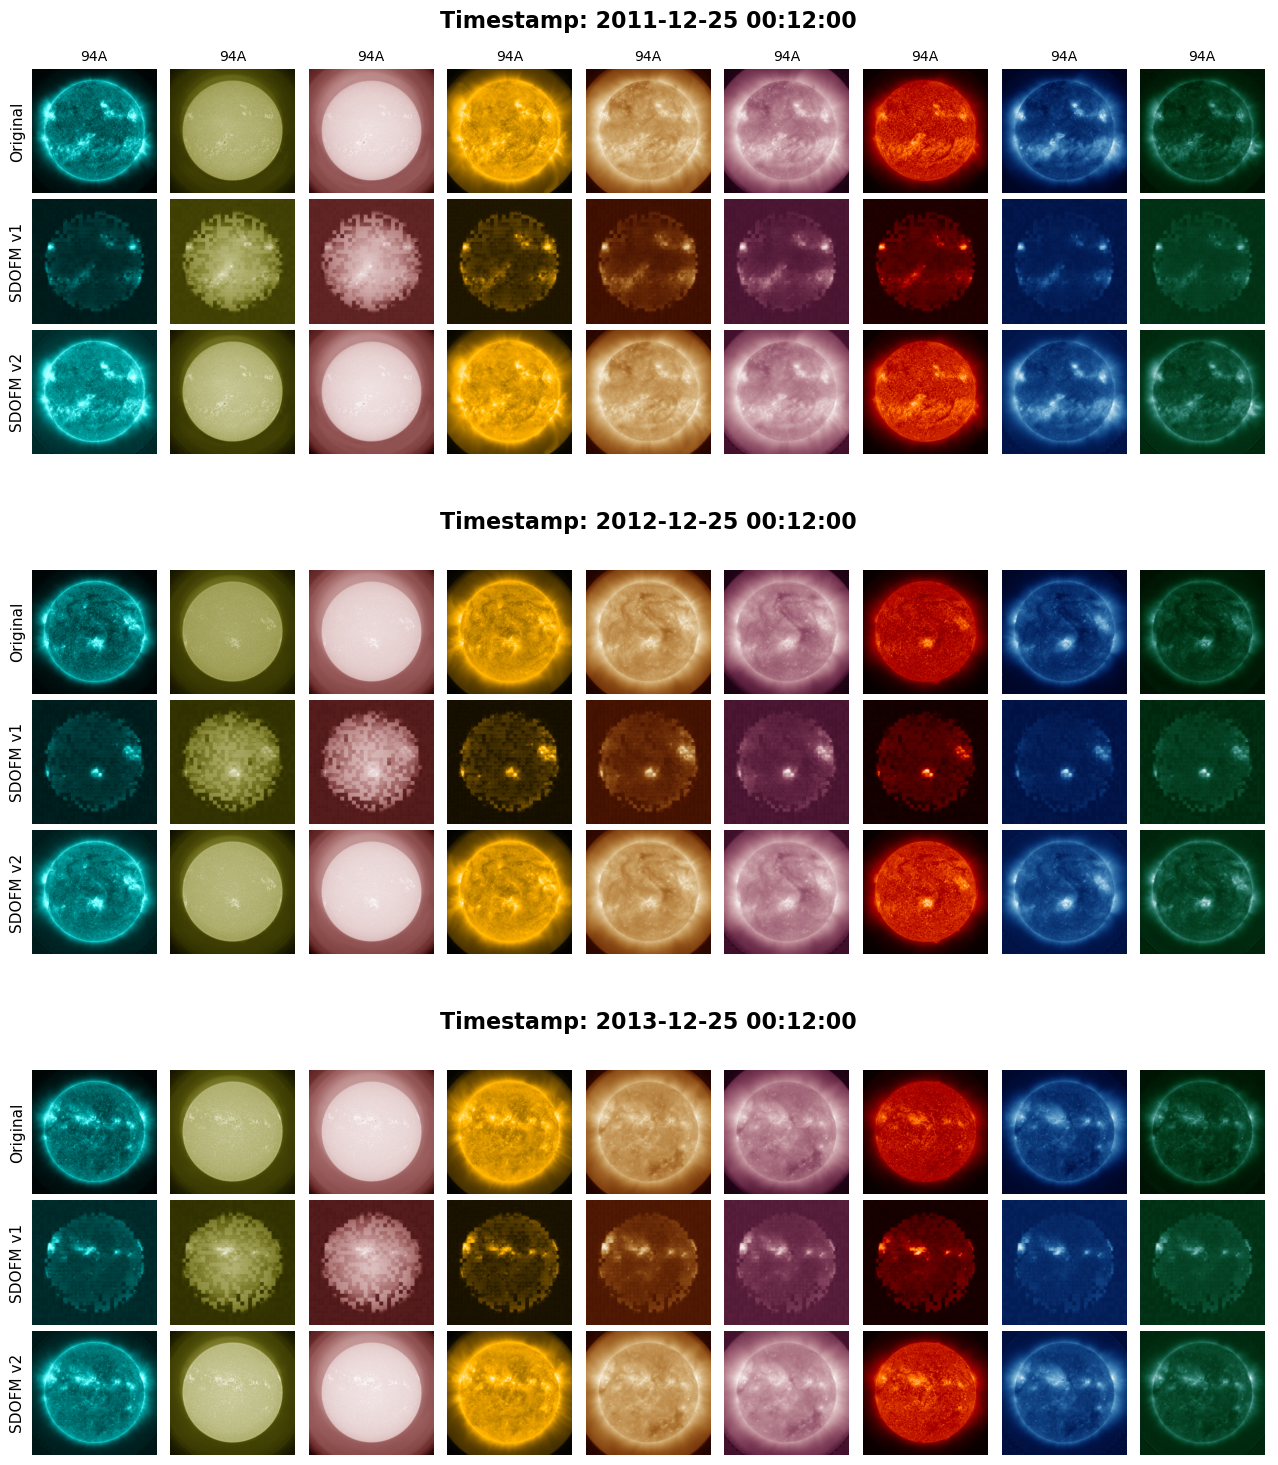

In [14]:
# Data setup (assuming your variables x_set, output, cms, sort_ids, ts exist)

row_labels = ["Original", "SDOFM v1", "SDOFM v2"]

fig = plt.figure(figsize=(16, 18))
outer_grid = gridspec.GridSpec(len(ts), 1, hspace=0.3, figure=fig)

for t_i, timestamp in enumerate(ts):
    inner_grid = gridspec.GridSpecFromSubplotSpec(3, 9, 
                                                  subplot_spec=outer_grid[t_i], 
                                                  wspace=0.05, hspace=0.05)
    
    # --- Add Timestamp Title ---
    ax_header = plt.Subplot(fig, outer_grid[t_i])
    fig.add_subplot(ax_header)
    ax_header.set_title(f"Timestamp: {timestamp}", fontsize=16, weight='bold', pad=30)
    ax_header.axis('off') # Hide the axis lines, just keep the title

    for row_idx in range(3): # Loop: Original, v1, v2
        for i, ch in enumerate(chan_types[:9]):
            
            # Create the subplot in the inner grid
            ax = plt.Subplot(fig, inner_grid[row_idx, i])
            fig.add_subplot(ax)
            
            # Turn off spines/ticks for clean look
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            
            # --- Plotting Logic ---
            if row_idx == 0:
                img_data = x_set[t_i, i, 0, :, :]

                if t_i == 0:
                    ax.set_title(f"{col}", fontsize=10)
                    
            elif row_idx == 1:
                # SDOFM v1
                img_data = output_old[1][t_i, i, 0, :, :]
            elif row_idx == 2:
                # SDOFM v2
                img_data = output[0][t_i, i, 0, :, :]
            
            ax.imshow(img_data, cmap=cms[i])

            if i == 0:
                ax.set_ylabel(row_labels[row_idx], fontsize=11, rotation=90, labelpad=5)

plt.savefig(f"SDOFMv2_comparision_with_sdofmv1_AIA.pdf", dpi=300, bbox_inches="tight")
plt.show()